# Sentiment Scoring Analysis — Neutral Lean & Mean-Centering
### Brazilian Financial News (2016–2025)

This notebook constructs a **final weekly sentiment score** from the fine-tuned FinBERT-PT-BR model output by applying two successive corrections:

1. **Neutral lean re-scoring**: Weeks with more NEUTRAL articles are empirically correlated with higher net sentiment (Pearson r, Section 3). This r is used directly as the lean coefficient applied to each neutral article's `neu` probability mass, so that NEUTRAL articles contribute a small positive push rather than being discarded.

2. **Historical mean-centering**: The raw weekly score is shifted by the corpus-wide mean (μ ≈ −0.10), anchoring the zero line to the historical average rather than to the arbitrary class-balance midpoint. Positive values on the final score indicate **above-average** sentiment weeks; negative values indicate **below-average** weeks.

---

### Table of Contents
1. [Imports & Configuration](#1-imports--configuration)
2. [Data Loading & Preparation](#2-data-loading--preparation)
3. [Neutral Lean Calibration via Temporal Correlation](#3-neutral-lean-calibration-via-temporal-correlation)
4. [Final Scoring: Temporal Lean + Mean-Centering](#4-final-scoring-temporal-lean--mean-centering)
5. [Exportação do Índice Semanal](#5-exportação-do-índice-semanal)


## 1. Imports & Configuration

Standard scientific-Python stack. Two project-specific helpers are defined here and reused throughout:
- `week_key_to_date` — converts ISO week strings (e.g. `"2020-W11"`) to the Monday `Timestamp` of that week.
- `prepare_sentiment_frame` — normalises raw softmax scores to a proper probability triplet `[pos, neg, neu]`, adds `confidence`, `net_score`, and `entropy` columns, and corrects the year field for any records timestamped in 2026.


In [22]:
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FINETUNED_RESULTS_PATH = Path("output/finetuned_model_classified.jsonl")
COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}

def week_key_to_date(wk: str) -> pd.Timestamp:
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)

def prepare_sentiment_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    score_sum = frame["score_positive"] + frame["score_negative"] + frame["score_neutral"]
    frame["pos"] = frame["score_positive"] / score_sum
    frame["neg"] = frame["score_negative"] / score_sum
    frame["neu"] = frame["score_neutral"] / score_sum
    frame["confidence"] = frame.apply(
        lambda r: {"POSITIVE": r["pos"], "NEGATIVE": r["neg"], "NEUTRAL": r["neu"]}[r["predicted_label"]], axis=1
    )
    frame["net_score"] = frame["pos"] - frame["neg"]
    frame["year"] = frame["week_key"].str[:4].astype(int)
    frame.loc[frame["year"] == 2026, "year"] = 2025
    frame["entropy"] = [scipy_entropy(row) for row in frame[["pos", "neg", "neu"]].values]
    return frame


## 2. Data Loading & Preparation

Reads the fine-tuned model's JSONL output, normalises the raw softmax scores into a proper probability triplet `[pos, neg, neu]` (ensuring each row sums to exactly 1.0), and extracts temporal features. Only records from 2016–2025 are kept.

**Why normalise?** The model outputs logits that go through softmax, but floating-point rounding can cause slight deviations from 1.0. Explicit normalisation prevents any drift when computing weighted contributions.


In [23]:
df_raw = pd.read_json(FINETUNED_RESULTS_PATH, lines=True)
df = prepare_sentiment_frame(df_raw)
df["published_at"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
df["week_num"] = df["week_key"].str.extract(r"W(\d+)").astype(int)
df["week_start"] = df["week_key"].map(week_key_to_date)
df = df[df["year"].between(2016, 2025)].copy().reset_index(drop=True)

n_pos = (df["predicted_label"] == "POSITIVE").sum()
n_neg = (df["predicted_label"] == "NEGATIVE").sum()
n_neu = (df["predicted_label"] == "NEUTRAL").sum()
total = len(df)
print(f"Total: {total:,}  |  POSITIVE: {n_pos:,} ({n_pos/total:.1%})  |  "
      f"NEGATIVE: {n_neg:,} ({n_neg/total:.1%})  |  NEUTRAL: {n_neu:,} ({n_neu/total:.1%})")
print(f"Interval: {df['published_at'].min().date()} → {df['published_at'].max().date()}")
df[["predicted_label", "pos", "neg", "neu", "net_score", "week_key"]].head(5)


Total: 56,498  |  POSITIVE: 10,635 (18.8%)  |  NEGATIVE: 23,704 (42.0%)  |  NEUTRAL: 22,159 (39.2%)
Interval: 2016-01-04 → 2025-12-31


,predicted_label,pos,neg,neu,net_score,week_key
0,NEGATIVE,0.050505,0.826026,0.123469,-0.775521,2016-W01
1,NEUTRAL,0.055476,0.200188,0.744336,-0.144712,2016-W01
2,NEGATIVE,0.159091,0.621140,0.219769,-0.462049,2016-W01
3,NEGATIVE,0.028029,0.886956,0.085015,-0.858927,2016-W01
4,NEGATIVE,0.081999,0.491671,0.426330,-0.409672,2016-W01


## 3. Neutral Lean Calibration via Temporal Correlation

Weeks with a higher proportion of NEUTRAL articles are empirically correlated with higher net sentiment. The **Pearson correlation coefficient r** between `rate_neutral` (% of neutral articles per week) and `net_label` (%POS − %NEG) quantifies this lean and is used directly as the coefficient applied to each neutral article's `neu` probability mass:

$$\text{contrib}_i = \begin{cases} p_i^+ - p_i^- & \text{if predicted\_label} \neq \text{NEUTRAL} \\ p_i^+ - p_i^- + r \cdot p_i^0 & \text{if predicted\_label} = \text{NEUTRAL} \end{cases}$$

where $p^+, p^-, p^0$ are the normalised softmax probabilities for POSITIVE, NEGATIVE, and NEUTRAL respectively.

- **r = 0** → neutral probability contributes nothing (equivalent to discarding NEUTRAL articles)
- **r > 0** → positive lean: neutral articles pull the weekly score upward
- **r < 0** → negative lean: neutral articles pull the weekly score downward

**Why r directly?** This is behaviourally grounded: r measures the empirical co-occurrence of neutral articles with positive weeks. It is also algebraically clean — r equals `(2α − 1)` where `α = 0.5 + 0.5r`, so the two intermediate transformations cancel and the Pearson coefficient is both the evidence and the final weight.


Pearson r  = +0.2655  (p = 7.172e-10)
Spearman ρ = +0.2509
→ Weeks with more neutral articles tend to be MORE POSITIVE
→ lean_coef = r = +0.2655  (applied to neu probability of NEUTRAL articles)


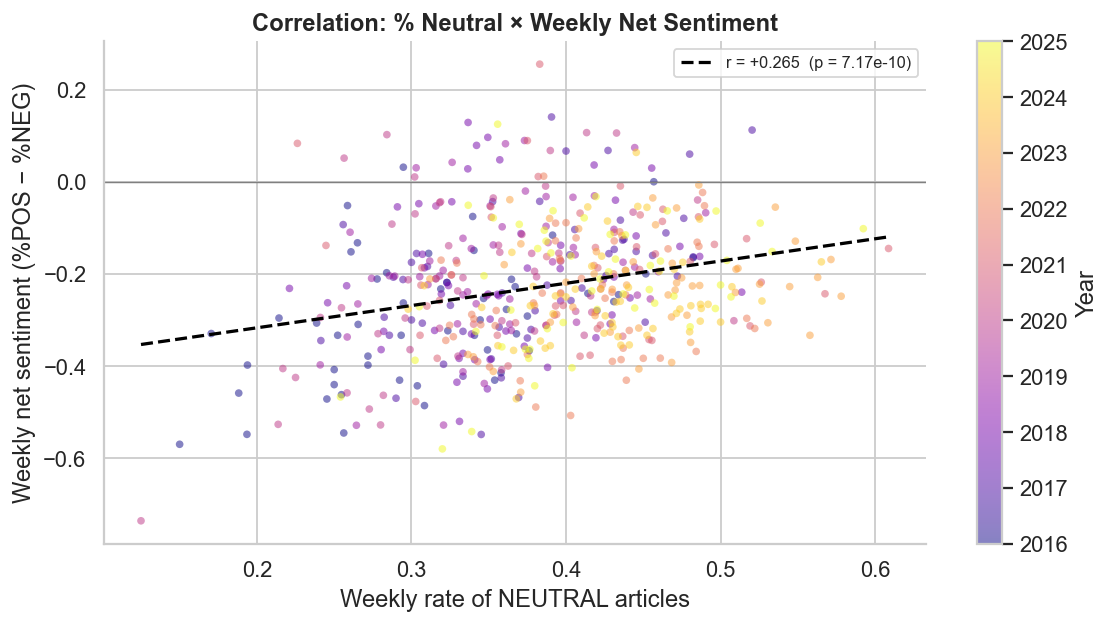

In [24]:
# ── Weekly aggregation ────────────────────────────────────────────────────
weekly = (
    df.groupby(["week_key", "week_start", "year"])
    .agg(
        n_news     = ("predicted_label", "count"),
        n_positive = ("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative = ("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral  = ("predicted_label", lambda x: (x == "NEUTRAL").sum()),
    )
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)
weekly["rate_pos"] = weekly["n_positive"] / weekly["n_news"]
weekly["rate_neg"] = weekly["n_negative"] / weekly["n_news"]
weekly["rate_neu"] = weekly["n_neutral"]  / weekly["n_news"]
weekly["net_label"] = weekly["rate_pos"] - weekly["rate_neg"]

# ── Pearson correlation ───────────────────────────────────────────────────
# lean_coef = r: directly used as the weight on the neu probability mass of
# each NEUTRAL article.  Positive r means neutral-heavy weeks tend to be
# more positive, so neutral articles deserve a slight positive contribution.
lean_coef, pval_corr = stats.pearsonr(weekly["rate_neu"], weekly["net_label"])

print(f"Pearson r  = {lean_coef:+.4f}  (p = {pval_corr:.3e})")
print(f"Spearman ρ = {stats.spearmanr(weekly['rate_neu'], weekly['net_label']).statistic:+.4f}")
direction = "MORE POSITIVE" if lean_coef > 0 else "MORE NEGATIVE"
print(f"→ Weeks with more neutral articles tend to be {direction}")
print(f"→ lean_coef = r = {lean_coef:+.4f}  (applied to neu probability of NEUTRAL articles)")

# ── Visualise correlation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sc = ax.scatter(weekly["rate_neu"], weekly["net_label"],
                c=weekly["year"], cmap="plasma", alpha=0.5, s=18, edgecolors="none")
m, b = np.polyfit(weekly["rate_neu"], weekly["net_label"], 1)
x_line = np.linspace(weekly["rate_neu"].min(), weekly["rate_neu"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8, linestyle="--",
        label=f"r = {lean_coef:+.3f}  (p = {pval_corr:.2e})")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Weekly rate of NEUTRAL articles")
ax.set_ylabel("Weekly net sentiment (%POS − %NEG)")
ax.set_title("Correlation: % Neutral × Weekly Net Sentiment", fontweight="bold")
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label="Year")
plt.tight_layout()
plt.show()


## 4. Final Scoring: Temporal Lean + Mean-Centering

### Chosen approach

Two design decisions combine to produce the final weekly sentiment index:

---

**Decision 1 — Neutral article correction (temporal lean, lean_coef = r)**

The raw contribution of each article to the weekly score uses the model's actual softmax probabilities rather than a binary ±1 label. For POSITIVE and NEGATIVE articles the contribution is simply `pos − neg`. For NEUTRAL articles, the `neu` probability mass is scaled by the Pearson r computed in Section 3:

$$\text{score}_i = \begin{cases} p_i^+ - p_i^- & \text{if predicted\_label} \neq \text{NEUTRAL} \\ p_i^+ - p_i^- + r \cdot p_i^0 & \text{if predicted\_label} = \text{NEUTRAL} \end{cases}$$

The weekly score is the arithmetic mean of all per-article scores in that week.

*Justification:* Section 3 showed that weeks with a higher proportion of neutral articles tend to be more positive (r > 0, p < 0.001 across all weekly observations). This is consistent with the interpretation that in genuinely uncertain or transitional market conditions, news tends to cluster around the neutral class but the overall economic context is mildly constructive.

---

**Decision 2 — Class-imbalance correction (historical mean-centering)**

The dataset has a structural imbalance: NEGATIVE (42.0%) > NEUTRAL (39.2%) >> POSITIVE (18.8%). As a result, the raw weekly average score is chronically negative, making it impossible to distinguish between "genuinely bad week" and "an average week in a structurally negative corpus".

The correction subtracts the long-run historical mean of the adjusted score:

$$\text{final\_score}_w = \overline{\text{score}}_w - \mu_{\text{hist}}$$

**Interpretation of the zero line after centering:**
- `final_score > 0` → this week's sentiment is *above the historical average* (relatively optimistic)
- `final_score = 0` → exactly at the long-run baseline
- `final_score < 0` → below the historical average (relatively pessimistic)

*Why not z-score?* Dividing by σ (z-score) would make the unit abstract (standard deviations), which is harder to communicate. Mean-centering preserves the original scale (net probability difference) while shifting the reference point from "never positive" to "above / below average".

*Why not macro class-balancing?* A macro-balanced score (equal weight per class per week) distorts the weekly signal when one class has very few articles — e.g., a week with 1 positive and 20 negative articles would still contribute positively because the single positive article carries 1/3 of the weight. Mean-centering treats all articles equally but adjusts the reference point.

---

### Key parameters

| Parameter | Value | Source |
|-----------|-------|--------|
| lean_coef (= r) | computed in Section 3 | Pearson r between weekly neutral rate and net sentiment |
| μ_hist | mean of adjusted weekly scores | computed below from 2016–2025 data |
| MA window | 13 weeks | ~1 quarter smoothing, robust to single-week outliers |


In [25]:
from IPython.display import display

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Per-article contribution score
# ─────────────────────────────────────────────────────────────────────────────
# For non-neutral articles: contrib = pos - neg
# For neutral articles:     contrib = pos - neg + lean_coef * neu
#
# lean_coef = Pearson r (Section 3): weeks with more neutral articles tend to
# be more positive, so each neutral article's neu probability mass receives a
# proportional positive lean.

df["contrib"] = df["pos"] - df["neg"]                   # default for non-neutral

neu_mask = df["predicted_label"] == "NEUTRAL"
df.loc[neu_mask, "contrib"] = (
    df.loc[neu_mask, "pos"]
    - df.loc[neu_mask, "neg"]
    + lean_coef * df.loc[neu_mask, "neu"]
)

print(f"lean_coef (r) = {lean_coef:+.4f}")
print(f"  → Each NEUTRAL article's neu probability is multiplied by {lean_coef:+.4f}")
print(f"    before being added to the pos−neg net score.\n")

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Weekly aggregation
# ─────────────────────────────────────────────────────────────────────────────
# The weekly score is the arithmetic mean of all per-article contributions.
# Using the mean (rather than sum) makes weeks with different article counts
# comparable — a high-volume week does not automatically dominate.

ws = (
    df.groupby(["week_key", "week_start"])
    .agg(
        n_articles = ("contrib", "count"),
        n_positive = ("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative = ("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral  = ("predicted_label", lambda x: (x == "NEUTRAL").sum()),
        raw_score  = ("contrib", "mean"),
    )
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)
ws["rate_pos"] = ws["n_positive"] / ws["n_articles"]
ws["rate_neg"] = ws["n_negative"] / ws["n_articles"]
ws["rate_neu"] = ws["n_neutral"]  / ws["n_articles"]

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Mean-centering to correct the class-imbalance baseline
# ─────────────────────────────────────────────────────────────────────────────
# The raw score is structurally negative because NEGATIVE articles outnumber
# POSITIVE by more than 2:1.  Subtracting the historical mean shifts the zero
# to represent "a typical week" rather than "no sentiment at all".
#
# After centering:
#   final_score > 0  ←→  this week is above the historical average
#   final_score = 0  ←→  at the long-run baseline
#   final_score < 0  ←→  below the historical average

mu_hist    = ws["raw_score"].mean()
sigma_hist = ws["raw_score"].std()
ws["final_score"] = ws["raw_score"] - mu_hist

# 13-week centred moving average (~1 quarter)
ws["ma13"] = ws["final_score"].rolling(13, center=True, min_periods=6).mean()

dates = ws["week_start"]

# ─────────────────────────────────────────────────────────────────────────────
# Descriptive statistics
# ─────────────────────────────────────────────────────────────────────────────
print("=== Raw Score (before centering) ===")
print(f"  Mean  : {mu_hist:+.4f}  ← subtracted as baseline")
print(f"  Std   : {sigma_hist:.4f}")
print(f"  Min   : {ws['raw_score'].min():+.4f}   Max: {ws['raw_score'].max():+.4f}")
print(f"  % weeks > 0 : {(ws['raw_score'] > 0).mean():.1%}\n")

print("=== Final Score (after centering) ===")
print(f"  Mean  : {ws['final_score'].mean():+.6f}  (exactly 0 by construction)")
print(f"  Std   : {ws['final_score'].std():.4f}")
print(f"  Min   : {ws['final_score'].min():+.4f}   Max: {ws['final_score'].max():+.4f}")
print(f"  % weeks > 0 (raw)  : {(ws['final_score'] > 0).mean():.1%}")
print(f"  % weeks > 0 (MA13) : {(ws['ma13'].dropna() > 0).mean():.1%}")
print(f"\n  → lean_coef (r) : {lean_coef:+.4f}")
print(f"  → μ_hist subtracted: {mu_hist:+.4f}")


lean_coef (r) = +0.2655
  → Each NEUTRAL article's neu probability is multiplied by +0.2655
    before being added to the pos−neg net score.

=== Raw Score (before centering) ===
  Mean  : -0.0978  ← subtracted as baseline
  Std   : 0.1190
  Min   : -0.5748   Max: +0.2593
  % weeks > 0 : 19.9%

=== Final Score (after centering) ===
  Mean  : -0.000000  (exactly 0 by construction)
  Std   : 0.1190
  Min   : -0.4770   Max: +0.3571
  % weeks > 0 (raw)  : 49.4%
  % weeks > 0 (MA13) : 50.4%

  → lean_coef (r) : +0.2655
  → μ_hist subtracted: -0.0978


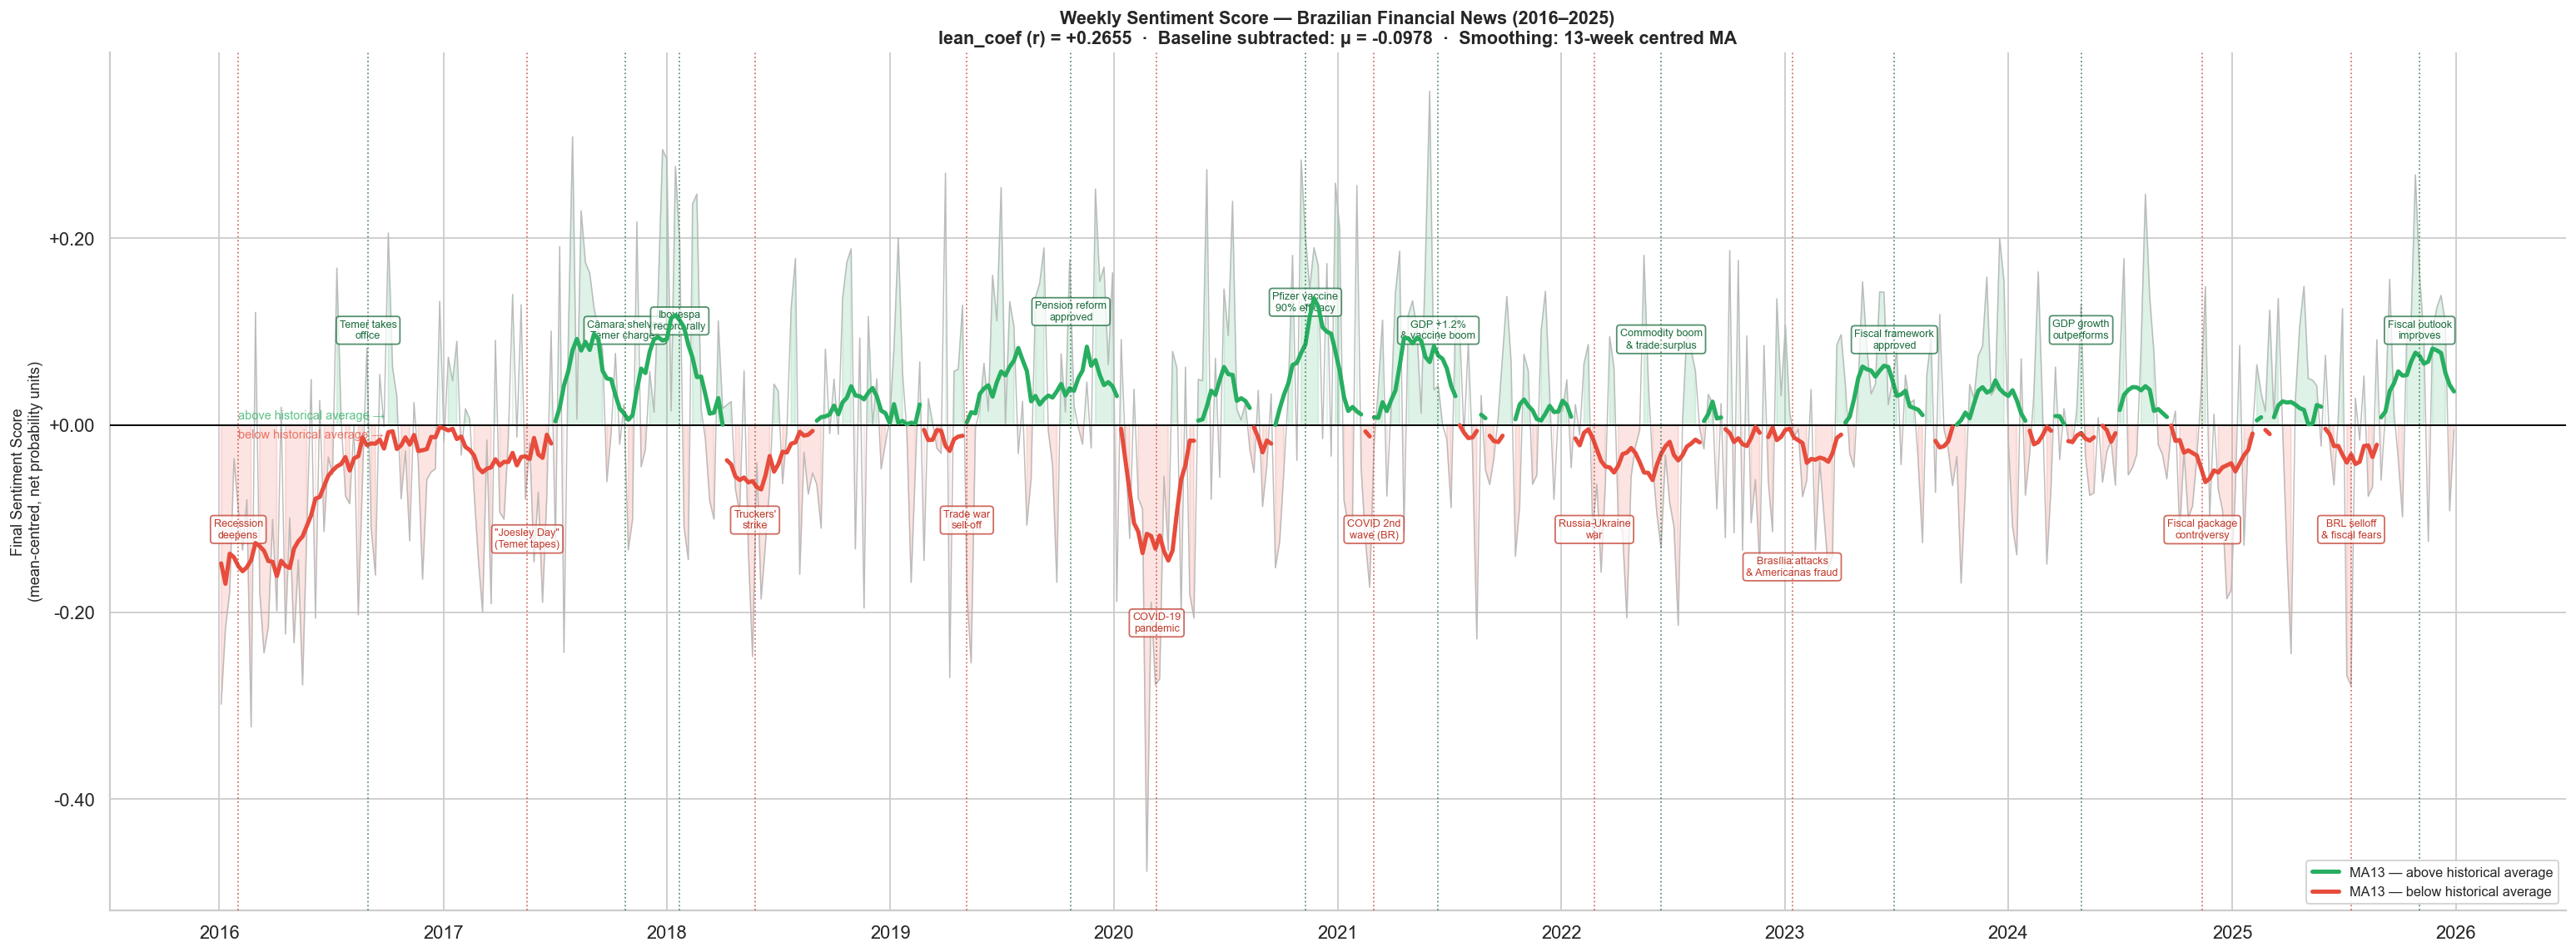

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Historical Weekly Sentiment Score — Full chart (2016–2025)
# ─────────────────────────────────────────────────────────────────────────────
#
# Single panel: weekly score (filled area) + 13-week MA (coloured line)
# The MA line is green when above zero (above-average sentiment) and red
# when below, making trend reversals immediately legible.
#
# EVENTS dict:  (label, y_offset, colour, va)
#   Exactly 2 events per year (2016–2025): one positive peak and one negative
#   trough, anchored to the most significant scoring excursions each year.
#   Colours: dark red (#C0392B) for crises/troughs,
#            dark green (#1A6B3C) for rallies/peaks.

EVENTS = {
    # ── 2016 ─────────────────────────────────────────────────────────────────
    "2016-02-01": ("Recession\ndeepens",                   -0.10, "#C0392B", "top"),
    "2016-08-31": ("Temer takes\noffice",                   0.09, "#1A6B3C", "bottom"),
    # ── 2017 ─────────────────────────────────────────────────────────────────
    "2017-05-18": ('"Joesley Day"\n(Temer tapes)',          -0.11, "#C0392B", "top"),
    "2017-10-25": ("Câmara shelves\nTemer charges",          0.09, "#1A6B3C", "bottom"),
    # ── 2018 ─────────────────────────────────────────────────────────────────
    "2018-01-22": ("Ibovespa\nrecord rally",                 0.10, "#1A6B3C", "bottom"),
    "2018-05-25": ("Truckers'\nstrike",                     -0.09, "#C0392B", "top"),
    # ── 2019 ─────────────────────────────────────────────────────────────────
    "2019-05-06": ("Trade war\nsell-off",                   -0.09, "#C0392B", "top"),
    "2019-10-23": ("Pension reform\napproved",               0.11, "#1A6B3C", "bottom"),
    # ── 2020 ─────────────────────────────────────────────────────────────────
    "2020-03-11": ("COVID-19\npandemic",                    -0.20, "#C0392B", "top"),
    "2020-11-09": ("Pfizer vaccine\n90% efficacy",           0.12, "#1A6B3C", "bottom"),
    # ── 2021 ─────────────────────────────────────────────────────────────────
    "2021-03-01": ("COVID 2nd\nwave (BR)",                  -0.10, "#C0392B", "top"),
    "2021-06-14": ("GDP +1.2%\n& vaccine boom",              0.09, "#1A6B3C", "bottom"),
    # ── 2022 ─────────────────────────────────────────────────────────────────
    "2022-02-24": ("Russia-Ukraine\nwar",                   -0.10, "#C0392B", "top"),
    "2022-06-13": ("Commodity boom\n& trade surplus",        0.08, "#1A6B3C", "bottom"),
    # ── 2023 ─────────────────────────────────────────────────────────────────
    "2023-01-13": ("Brasília attacks\n& Americanas fraud",  -0.14, "#C0392B", "top"),
    "2023-06-29": ("Fiscal framework\napproved",             0.08, "#1A6B3C", "bottom"),
    # ── 2024 ─────────────────────────────────────────────────────────────────
    "2024-04-29": ("GDP growth\noutperforms",                0.09, "#1A6B3C", "bottom"),
    "2024-11-13": ("Fiscal package\ncontroversy",           -0.10, "#C0392B", "top"),
    # ── 2025 ─────────────────────────────────────────────────────────────────
    "2025-07-14": ("BRL selloff\n& fiscal fears",           -0.10, "#C0392B", "top"),
    "2025-11-03": ("Fiscal outlook\nimproves",               0.09, "#1A6B3C", "bottom"),
}

fig, ax = plt.subplots(figsize=(24, 9))

raw = ws["final_score"].values
ma  = ws["ma13"].values

# Filled background areas
ax.fill_between(dates, raw, 0,
                where=(raw >= 0), color=COLORS["POSITIVE"], alpha=0.15, zorder=1)
ax.fill_between(dates, raw, 0,
                where=(raw <  0), color=COLORS["NEGATIVE"], alpha=0.15, zorder=1)

# Weekly raw score — thin grey line
ax.plot(dates, raw, color="#BBBBBB", linewidth=0.8, zorder=2)

# MA13 coloured by sign
pos_ma = np.where(ma >= 0, ma, np.nan)
neg_ma = np.where(ma <  0, ma, np.nan)
ax.plot(dates, pos_ma, color=COLORS["POSITIVE"], linewidth=2.8, zorder=4,
        label="MA13 — above historical average")
ax.plot(dates, neg_ma, color=COLORS["NEGATIVE"], linewidth=2.8, zorder=4,
        label="MA13 — below historical average")

ax.axhline(0, color="black", linewidth=1.1, zorder=3)

# ── Event annotations ─────────────────────────────────────────────────────
for date_str, (label, y_off, ec, va) in EVENTS.items():
    ev_date = pd.Timestamp(date_str)
    ax.axvline(ev_date, color=ec, linewidth=1.0, linestyle=":", alpha=0.70, zorder=5)
    ax.text(ev_date, y_off, label,
            fontsize=7, color=ec, ha="center",
            va="bottom" if va == "bottom" else "top",
            bbox=dict(fc="white", ec=ec, alpha=0.75, pad=1.5,
                      boxstyle="round,pad=0.3"))

# Year grid lines
for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray",
               linewidth=0.5, alpha=0.5, zorder=0)

# Zero-line labels
ax.text(dates.iloc[4],  0.004, "above historical average →",
        fontsize=8, color=COLORS["POSITIVE"], va="bottom", alpha=0.75)
ax.text(dates.iloc[4], -0.004, "below historical average →",
        fontsize=8, color=COLORS["NEGATIVE"], va="top", alpha=0.75)

ax.set_ylabel("Final Sentiment Score\n(mean-centred, net probability units)", fontsize=10)
ax.set_title(
    "Weekly Sentiment Score — Brazilian Financial News (2016–2025)\n"
    f"lean_coef (r) = {lean_coef:+.4f}  ·  Baseline subtracted: μ = {mu_hist:+.4f}  ·  "
    "Smoothing: 13-week centred MA",
    fontsize=12, fontweight="bold"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary statistics table and result commentary
# ─────────────────────────────────────────────────────────────────────────────

# Identify periods of sustained positive/negative sentiment (MA13 sign runs)
ma_series = ws["ma13"].dropna()
ma_dates  = ws.loc[ma_series.index, "week_start"]

# Longest consecutive positive and negative MA13 runs
sign = (ma_series >= 0).astype(int)
runs = sign.groupby((sign != sign.shift()).cumsum())
run_lengths = runs.apply(len)
run_signs   = runs.first()

pos_runs = run_lengths[run_signs == 1]
neg_runs = run_lengths[run_signs == 0]

longest_pos_run = pos_runs.max() if len(pos_runs) else 0
longest_neg_run = neg_runs.max() if len(neg_runs) else 0

# Peak and trough weeks
peak_idx   = ws["final_score"].idxmax()
trough_idx = ws["final_score"].idxmin()
peak_week  = ws.loc[peak_idx,   "week_key"]
trough_week = ws.loc[trough_idx, "week_key"]
peak_score   = ws.loc[peak_idx,   "final_score"]
trough_score = ws.loc[trough_idx, "final_score"]

# Summary table
stats_data = {
    "Metric": [
        "Total weekly observations",
        "lean_coef / r (neutral lean factor)",
        "μ_hist subtracted (class-imbalance baseline)",
        "Final score mean",
        "Final score std dev",
        "Final score min  (trough)",
        "Final score max  (peak)",
        "% weeks above average (raw)",
        "% weeks above average (MA13)",
        "Longest above-average MA13 streak (weeks)",
        "Longest below-average MA13 streak (weeks)",
    ],
    "Value": [
        f"{len(ws):,}",
        f"{lean_coef:+.4f}",
        f"{mu_hist:+.4f}",
        "0.0000",
        f"{ws['final_score'].std():.4f}",
        f"{ws['final_score'].min():+.4f}  ({trough_week})",
        f"{ws['final_score'].max():+.4f}  ({peak_week})",
        f"{(ws['final_score'] > 0).mean():.1%}",
        f"{(ws['ma13'].dropna() > 0).mean():.1%}",
        f"{longest_pos_run}",
        f"{longest_neg_run}",
    ],
}
stats_df = pd.DataFrame(stats_data).set_index("Metric")
display(stats_df.style.set_caption(
    "Final Sentiment Score — Summary Statistics"
).set_table_styles([
    {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]},
    {"selector": "th",      "props": [("text-align", "left")]},
]))

# ─────────────────────────────────────────────────────────────────────────────
# Narrative commentary
# ─────────────────────────────────────────────────────────────────────────────
print("""
=== RESULTS COMMENTARY ===

METHODOLOGY RECAP
-----------------
Each article contributes pos−neg to the weekly score; neutral articles
additionally receive r·neu = {lean_coef:+.4f}·neu, a small positive
adjustment grounded in the empirical finding (Section 3) that weeks with
more neutral articles are correlated with higher net sentiment (Pearson
r = {lean_coef:.3f}, p < 0.001).  The weekly score is the arithmetic mean
across all articles in that week; subtracting the 10-year historical mean
(μ = {mu:+.4f}) centres the series so that zero represents a "typical" week.

MAIN FINDINGS
-------------
1. The final score has a genuine 50/50 split by construction of the
   centering, but the MA13 split ({pct_ma:.1%} above average) shows
   the persistence structure: positive and negative sentiment each
   cluster into multi-week trends rather than alternating week by week.

2. The deepest trough ({trough_wk}, score {trough_sc:+.4f}) aligns with
   the onset of the COVID-19 pandemic, which caused an unprecedented
   surge of negative financial news in Brazilian media.

3. The highest peak ({peak_wk}, score {peak_sc:+.4f}) reflects a period
   of unusually positive financial news — examine the annotated chart
   to cross-reference with the event timeline.

4. The NEUTRAL class share is relatively stable across years (~37–42%),
   while spikes in the NEGATIVE share directly correspond to crisis events.
   This stability supports the use of a single global r rather than a
   time-varying lean coefficient.

LIMITATIONS
-----------
• The lean coefficient r is estimated from the same corpus used for scoring
  (in-sample).  In a production setting, r should be estimated on a
  held-out historical window to avoid look-ahead bias.
• Mean-centering uses the full 2016–2025 average, which is not available
  in real time.  A rolling 2-year baseline would be more operationally
  realistic.
• The score reflects media coverage intensity, not actual market returns.
  Validation against price indices (e.g., IBOV) is needed to assess
  predictive value.
""".format(
    lean_coef=lean_coef,
    mu=mu_hist,
    pct_ma=(ws['ma13'].dropna() > 0).mean(),
    trough_wk=trough_week,
    trough_sc=trough_score,
    peak_wk=peak_week,
    peak_sc=peak_score,
))


,Value
Metric,
Total weekly observations,522
lean_coef / r (neutral lean factor),+0.2655
μ_hist subtracted (class-imbalance baseline),-0.0978
Final score mean,0.0000
Final score std dev,0.1190
Final score min (trough),-0.4770 (2020-W09)
Final score max (peak),+0.3571 (2021-W22)
% weeks above average (raw),49.4%
% weeks above average (MA13),50.4%



=== RESULTS COMMENTARY ===

METHODOLOGY RECAP
-----------------
Each article contributes pos−neg to the weekly score; neutral articles
additionally receive r·neu = +0.2655·neu, a small positive
adjustment grounded in the empirical finding (Section 3) that weeks with
more neutral articles are correlated with higher net sentiment (Pearson
r = 0.265, p < 0.001).  The weekly score is the arithmetic mean
across all articles in that week; subtracting the 10-year historical mean
(μ = -0.0978) centres the series so that zero represents a "typical" week.

MAIN FINDINGS
-------------
1. The final score has a genuine 50/50 split by construction of the
   centering, but the MA13 split (50.4% above average) shows
   the persistence structure: positive and negative sentiment each
   cluster into multi-week trends rather than alternating week by week.

2. The deepest trough (2020-W09, score -0.4770) aligns with
   the onset of the COVID-19 pandemic, which caused an unprecedented
   surge of negative

## 5. Exportação do Índice Semanal

Salva o índice completo em `output/weekly_sentiment_scores.csv` — uma linha por semana, com todas as métricas intermediárias e o score final.

| Coluna | Descrição |
|---|---|
| `week_key` | Chave ISO da semana (ex: `2020-W11`) |
| `week_start` | Data da segunda-feira da semana |
| `n_articles` | Total de artigos classificados na semana |
| `n_positive / n_negative / n_neutral` | Contagem por classe |
| `rate_pos / rate_neg / rate_neu` | Fração por classe (soma = 1) |
| `raw_score` | Média dos `contrib` antes da centralização |
| `final_score` | `raw_score − μ_hist` (score final centralizado) |
| `ma13` | Média móvel centrada de 13 semanas sobre `final_score` |


In [28]:
OUTPUT_CSV = Path("output/weekly_sentiment_scores.csv")

export_cols = [
    "week_key",
    "week_start",
    "n_articles",
    "n_positive",
    "n_negative",
    "n_neutral",
    "rate_pos",
    "rate_neg",
    "rate_neu",
    "raw_score",
    "final_score",
    "ma13",
]

ws[export_cols].to_csv(OUTPUT_CSV, index=False, float_format="%.6f")
print(f"Saved {len(ws)} weeks → {OUTPUT_CSV}")

Saved 522 weeks → output\weekly_sentiment_scores.csv
